# Figure 5 — Preferential NB-NB adhesion is not required for mutant NB clustering

Compares simulated *mud* mutant lineages with vs without preferential NB-NB adhesion, restricted to the two regulatory dynamics that came closest to the experimental range under VCV=1 (volume-ABM and volume-PDE).

- **A** — paired representative lineages (with vs without adhesion) for each regulatory dynamic
- **B** — paired distributions of normalized heterotypic contact fraction (`norm_het_frac`)
- **C** — paired distributions of NB exposure fraction (`exposed_frac`)
- **D** — paired distributions of homotypic NB contact fraction (computed here)

Conditions: `mudmut_divMean0Stdev26_rotMean0Stdev30` (with adhesion) vs `_noadhesion`. sim43 = VOL-ABM, sim45 = VOL-PDE; VCV=1 only.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "npa").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from the current working directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from npa.sim_viz import load_raw_snapshot_full, render_raw

FIG_DIR = REPO_ROOT / "docs" / "tex_draft" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 300,
    "svg.fonttype": "none",
})

print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {FIG_DIR}")


Repo root: /sessions/zen-laughing-franklin/mnt/neurogen-plane-rotation-analysis
Output dir: /sessions/zen-laughing-franklin/mnt/neurogen-plane-rotation-analysis/docs/tex_draft/figures


In [2]:
DS_UM_PER_VOX = 0.3
AREA_SCALE = DS_UM_PER_VOX ** 2

MUD_BASE = "mudmut_divMean0Stdev26_rotMean0Stdev30"
MUD_NOADH = "mudmut_divMean0Stdev26_rotMean0Stdev30_noadhesion"

# (sim_id, regulatory_dynamic key, display label)
SIM_MAP: list[tuple[str, str, str]] = [
    ("sim43", "VOL-ABM", "volume (ABM)"),
    ("sim45", "VOL-PDE", "volume (PDE)"),
]
VCV_MODE = 1

ADH_FILL = {"with": "#5f5f5f", "without": "#d9d9d9"}
ADH_LABEL = {"with": "with NB–NB adhesion", "without": "without NB–NB adhesion"}

SIM_METRICS_CSV = REPO_ROOT / "data" / "sim" / "processed_div26" / "sim_metrics_last.csv"
SIM_RUN_INDEX_CSV = REPO_ROOT / "data" / "sim" / "processed_div26" / "sim_run_index.csv"
HET_METRICS_CSV = REPO_ROOT / "data" / "sim" / "processed_adhesion" / "het_contact_metrics.csv"
EXP_METRICS_CSV = REPO_ROOT / "data" / "sim" / "processed_adhesion" / "nb_exposure_metrics.csv"


In [3]:
sim_metrics_df = pd.read_csv(SIM_METRICS_CSV)
run_index_df = pd.read_csv(SIM_RUN_INDEX_CSV)
het_df = pd.read_csv(HET_METRICS_CSV)
exp_df = pd.read_csv(EXP_METRICS_CSV)


def _filter_scope(df: pd.DataFrame) -> pd.DataFrame:
    out = df[
        (df["condition"].isin([MUD_BASE, MUD_NOADH]))
        & (df["sim_id"].isin([sid for sid, _, _ in SIM_MAP]))
        & (df["critical_volume_mode"] == VCV_MODE)
    ].copy()
    out["adhesion_state"] = out["condition"].map(lambda c: "without" if "noadhesion" in c else "with")
    return out


sim_metrics = _filter_scope(sim_metrics_df)
het = _filter_scope(het_df)
exp = _filter_scope(exp_df)

print(f"sim_metrics rows: {len(sim_metrics)}    het rows: {len(het)}    exp rows: {len(exp)}")


sim_metrics rows: 200    het rows: 200    exp rows: 200


In [4]:
def content_bbox(arr: np.ndarray, pad: int = 6) -> tuple[int, int, int, int]:
    occ = arr.any(axis=-1) if arr.ndim == 3 else arr > 0
    ys, xs = np.where(occ)
    if len(xs) == 0:
        h, w = arr.shape[:2]
        return 0, 0, h, w
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, arr.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, arr.shape[1])
    return y0, x0, y1, x1


def uniform_crop_size(geo_arrays: list[np.ndarray], pad: int = 6) -> int:
    max_dim = 0
    for arr in geo_arrays:
        y0, x0, y1, x1 = content_bbox(arr, pad=pad)
        max_dim = max(max_dim, y1 - y0, x1 - x0)
    return max_dim


def crop_centered(arr: np.ndarray, target_size: int) -> np.ndarray:
    occ = arr.any(axis=-1) if arr.ndim == 3 else arr > 0
    ys, xs = np.where(occ)
    if len(xs) == 0:
        cy, cx = arr.shape[0] // 2, arr.shape[1] // 2
    else:
        cy = (int(ys.min()) + int(ys.max())) // 2
        cx = (int(xs.min()) + int(xs.max())) // 2
    half = target_size // 2
    y0 = max(0, min(cy - half, arr.shape[0] - target_size))
    x0 = max(0, min(cx - half, arr.shape[1] - target_size))
    if arr.ndim == 3:
        return arr[y0:y0 + target_size, x0:x0 + target_size, :]
    return arr[y0:y0 + target_size, x0:x0 + target_size]


def pick_percentile_run(df: pd.DataFrame, metric: str, percentile: float) -> pd.Series:
    target = df[metric].quantile(percentile)
    candidates = df.assign(abs_delta=(df[metric] - target).abs()).sort_values(
        ["abs_delta", metric, "run_id"], kind="stable"
    )
    return candidates.iloc[0]


def pick_mean_run(df: pd.DataFrame, metric: str) -> pd.Series:
    target = df[metric].mean()
    candidates = df.assign(abs_delta=(df[metric] - target).abs()).sort_values(
        ["abs_delta", metric, "run_id"], kind="stable"
    )
    return candidates.iloc[0]


def load_run_snapshot(condition: str, sim_id: str, run_id: int) -> tuple[np.ndarray, np.ndarray]:
    row = run_index_df.loc[
        (run_index_df["condition"] == condition)
        & (run_index_df["sim_id"] == sim_id)
        & (run_index_df["run_id"].astype(int) == int(run_id))
    ].iloc[0]
    cells_path = REPO_ROOT / row["cells_path"]
    locs_path = REPO_ROOT / row["locs_path"]
    return load_raw_snapshot_full(cells_path, locs_path)


def homotypic_nb_contact_fraction(geo_raw: np.ndarray, label_map: np.ndarray) -> float:
    """Of all inter-cell contacts that involve at least one NB, what fraction are NB-NB?

    Uses label_map to mask out intra-cell pixel adjacencies so a single large NB
    surrounded by non-NBs doesn't trivially score as homotypic.
    """
    nb = geo_raw[..., 0] > 0
    nonnb = (geo_raw[..., 1] > 0) | (geo_raw[..., 2] > 0)

    diff_h = label_map[:, :-1] != label_map[:, 1:]
    diff_v = label_map[:-1, :] != label_map[1:, :]

    nb_nb_h = diff_h & nb[:, :-1] & nb[:, 1:]
    nb_nb_v = diff_v & nb[:-1, :] & nb[1:, :]

    nb_other_h = diff_h & ((nb[:, :-1] & nonnb[:, 1:]) | (nonnb[:, :-1] & nb[:, 1:]))
    nb_other_v = diff_v & ((nb[:-1, :] & nonnb[1:, :]) | (nonnb[:-1, :] & nb[1:, :]))

    n_nb_nb = int(nb_nb_h.sum() + nb_nb_v.sum())
    n_nb_other = int(nb_other_h.sum() + nb_other_v.sum())
    n_total = n_nb_nb + n_nb_other
    return float(n_nb_nb / n_total) if n_total > 0 else np.nan


def style_publication_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#d0d0d0", linewidth=0.6, alpha=0.5)
    ax.tick_params(axis="x", length=0)


## Compute homotypic NB contact fraction for all paired runs

Run once; the result populates a long-form dataframe used by panel D. Loads ~200 raw geo tensors so this cell takes a few seconds.


In [5]:
homo_records = []
for sid, dyn_key, dyn_label in SIM_MAP:
    for cond, state in [(MUD_BASE, "with"), (MUD_NOADH, "without")]:
        subset = run_index_df[
            (run_index_df["condition"] == cond)
            & (run_index_df["sim_id"] == sid)
        ]
        for _, row in subset.iterrows():
            geo_raw, label_map = load_raw_snapshot_full(REPO_ROOT / row["cells_path"], REPO_ROOT / row["locs_path"])
            f = homotypic_nb_contact_fraction(geo_raw, label_map)
            homo_records.append({
                "sim_id": sid,
                "regulatory_dynamic": dyn_key,
                "adhesion_state": state,
                "run_id": int(row["run_id"]),
                "homotypic_nb_frac": f,
            })

homo_df = pd.DataFrame(homo_records)
print(f"computed homotypic_nb_frac for {len(homo_df)} runs")
homo_df.head()


computed homotypic_nb_frac for 200 runs


,sim_id,regulatory_dynamic,adhesion_state,run_id,homotypic_nb_frac
0,sim43,VOL-ABM,with,1,0.272727
1,sim43,VOL-ABM,with,2,0.000000
2,sim43,VOL-ABM,with,3,0.296296
3,sim43,VOL-ABM,with,4,0.000000
4,sim43,VOL-ABM,with,5,0.552239


## Panel A — paired representative lineages

50th-percentile-by-lineage-area runs from each (regulatory dynamic × adhesion) combination. Rows = regulatory dynamic; columns = adhesion state. Universal crop dimension applied across all four lineages.


panel A uniform crop: 111x111 voxels (33.3x33.3 µm)


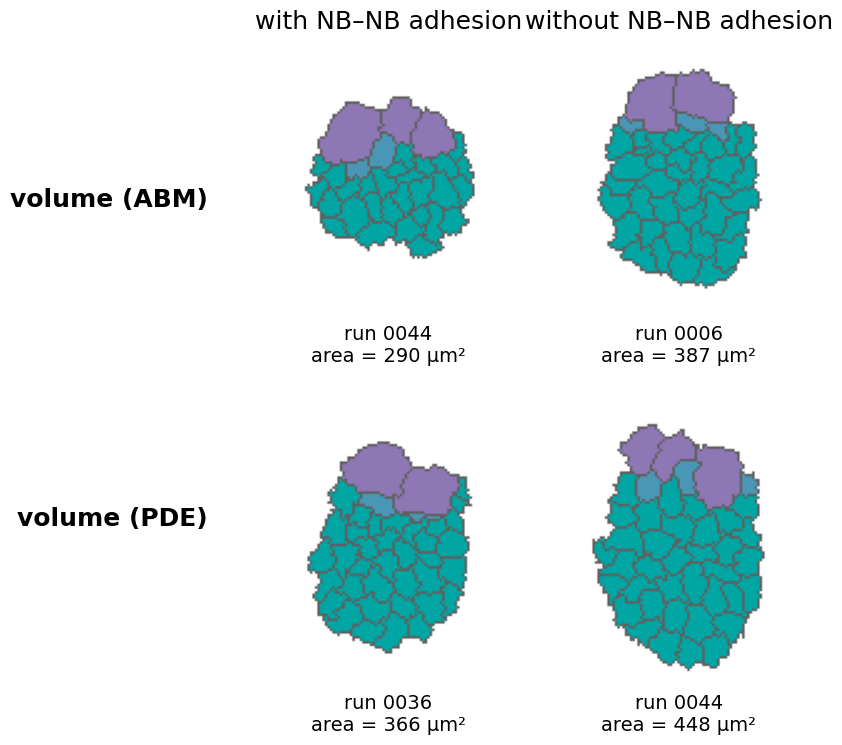

In [6]:
def panel_a() -> plt.Figure:
    fig, axes = plt.subplots(2, 2, figsize=(7.0, 7.6))

    snapshots = []
    for row_idx, (sid, dyn_key, dyn_label) in enumerate(SIM_MAP):
        for col_idx, (cond, state) in enumerate([(MUD_BASE, "with"), (MUD_NOADH, "without")]):
            homo_subset = homo_df[
                (homo_df["sim_id"] == sid)
                & (homo_df["adhesion_state"] == state)
            ]
            rep_homo = pick_mean_run(homo_subset, "homotypic_nb_frac")
            run_id = int(rep_homo["run_id"])
            area_row = sim_metrics[
                (sim_metrics["condition"] == cond)
                & (sim_metrics["sim_id"] == sid)
                & (sim_metrics["run_id"] == run_id)
            ].iloc[0]
            rep = pd.Series({
                "run_id": run_id,
                "lin_area_vox": area_row["lin_area_vox"],
                "homotypic_nb_frac": rep_homo["homotypic_nb_frac"],
            })
            geo_raw, label_map = load_run_snapshot(cond, sid, run_id)
            snapshots.append((row_idx, col_idx, dyn_label, state, geo_raw, label_map, rep))

    target_size = uniform_crop_size([s[4] for s in snapshots], pad=6)
    print(f"panel A uniform crop: {target_size}x{target_size} voxels "
          f"({target_size * DS_UM_PER_VOX:.1f}x{target_size * DS_UM_PER_VOX:.1f} µm)")

    for col_idx, state in enumerate(["with", "without"]):
        axes[0, col_idx].set_title(ADH_LABEL[state], fontsize=18, pad=8)

    for row_idx, col_idx, dyn_label, state, geo_raw, label_map, rep in snapshots:
        ax = axes[row_idx, col_idx]
        geo_crop = crop_centered(geo_raw, target_size)
        label_crop = crop_centered(label_map, target_size)
        render_raw(geo_crop, ax=ax, label_map=label_crop, title="")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xlabel(
            f"run {int(rep['run_id']):04d}\narea = {rep['lin_area_vox'] * AREA_SCALE:.0f} µm²",
            fontsize=14,
            labelpad=2,
        )
        ax.xaxis.set_label_coords(0.5, -0.03)

    for row_idx, (_, _, dyn_label) in enumerate(SIM_MAP):
        bbox = axes[row_idx, 0].get_position()
        fig.text(
            bbox.x0 - 0.005,
            (bbox.y0 + bbox.y1) / 2,
            dyn_label,
            ha="right",
            va="center",
            fontsize=18,
            fontweight="bold",
        )

    fig.subplots_adjust(left=0.18, right=0.99, top=0.92, bottom=0.06, wspace=0.05, hspace=0.30)
    return fig


fig_a = panel_a()
fig_a.savefig(FIG_DIR / "figure5_paired_lineages_panel.png", bbox_inches="tight", facecolor="white")
fig_a.savefig(FIG_DIR / "figure5_paired_lineages_panel.svg", bbox_inches="tight", facecolor="white")
fig_a.savefig(FIG_DIR / "figure5_paired_lineages_panel.pdf", bbox_inches="tight", facecolor="white")
plt.show()


## Panels B / C / D — paired metrics

`make_paired_panel` draws two side-by-side boxes per regulatory dynamic (with adhesion vs without), and prints the mean absolute paired delta on each group. Reuse for `norm_het_frac`, `exposed_frac`, and `homotypic_nb_frac`.


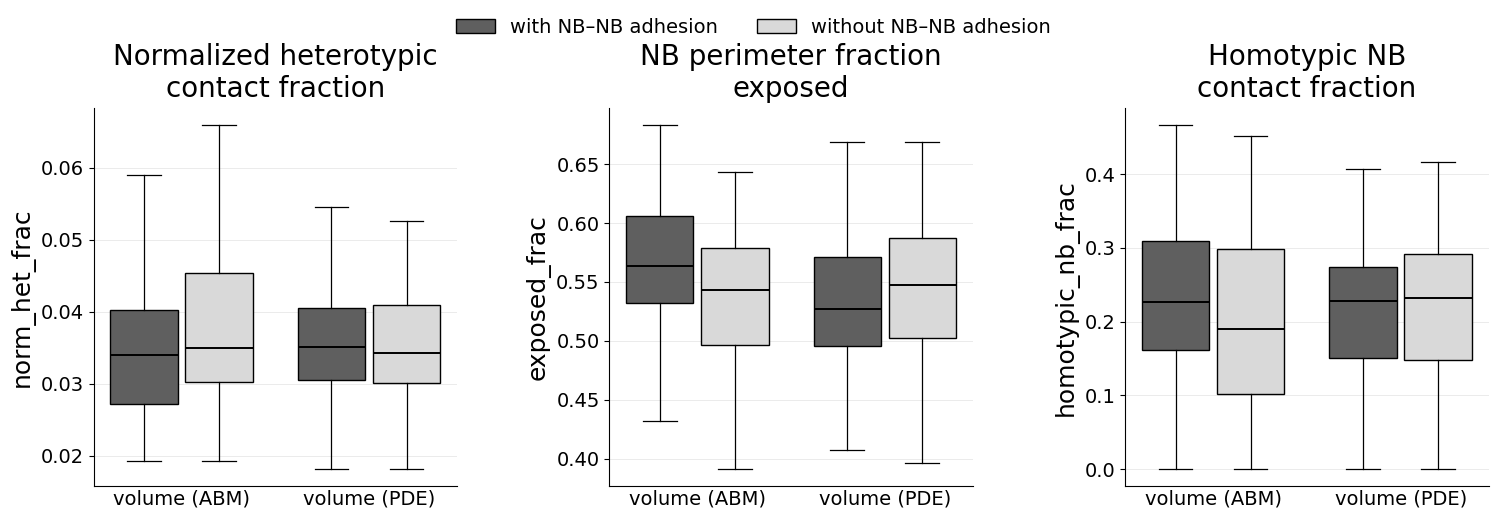

In [7]:
def make_paired_panel(ax: plt.Axes, df: pd.DataFrame, value_col: str, title: str, ylabel: str | None = None) -> None:
    box_width = 0.36
    centers = np.arange(1, len(SIM_MAP) + 1, dtype=float)

    for state, offset in [("with", -box_width / 2 - 0.02), ("without", +box_width / 2 + 0.02)]:
        values = []
        for sid, _, _ in SIM_MAP:
            subset = df[(df["sim_id"] == sid) & (df["adhesion_state"] == state)]
            values.append(subset[value_col].astype(float).to_numpy())
        positions = centers + offset
        ax.boxplot(
            values,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.4},
            boxprops={"facecolor": ADH_FILL[state], "edgecolor": "black", "linewidth": 1.0},
            whiskerprops={"color": "black", "linewidth": 0.9},
            capprops={"color": "black", "linewidth": 0.9},
            manage_ticks=False,
            zorder=3,
        )

    ax.set_xticks(centers, [dyn for _, _, dyn in SIM_MAP])
    ax.set_title(title, fontsize=20, pad=8)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis="x", labelsize=14, pad=2)
    ax.tick_params(axis="y", labelsize=14)
    style_publication_axis(ax)


def panels_bcd() -> plt.Figure:
    fig, axes = plt.subplots(1, 3, figsize=(15.0, 5.4))
    make_paired_panel(axes[0], het, "norm_het_frac",
                      title="Normalized heterotypic\ncontact fraction",
                      ylabel="norm_het_frac")
    make_paired_panel(axes[1], exp, "exposed_frac",
                      title="NB perimeter fraction\nexposed",
                      ylabel="exposed_frac")
    make_paired_panel(axes[2], homo_df, "homotypic_nb_frac",
                      title="Homotypic NB\ncontact fraction",
                      ylabel="homotypic_nb_frac")

    handles = [
        Patch(facecolor=ADH_FILL["with"], edgecolor="black", label=ADH_LABEL["with"]),
        Patch(facecolor=ADH_FILL["without"], edgecolor="black", label=ADH_LABEL["without"]),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=2,
        frameon=False,
        fontsize=14,
        bbox_to_anchor=(0.5, 1.02),
    )
    fig.subplots_adjust(left=0.06, right=0.99, top=0.82, bottom=0.12, wspace=0.42)
    return fig


fig_bcd = panels_bcd()
fig_bcd.savefig(FIG_DIR / "figure5_paired_metrics_panel.png", bbox_inches="tight", facecolor="white")
fig_bcd.savefig(FIG_DIR / "figure5_paired_metrics_panel.svg", bbox_inches="tight", facecolor="white")
fig_bcd.savefig(FIG_DIR / "figure5_paired_metrics_panel.pdf", bbox_inches="tight", facecolor="white")
plt.show()
